In [1]:
# Step 1: Libraries import cheyyi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Step 2: Dataset load cheyyi
df = pd.read_csv(r'C:\Users\SRINIVAS PADMA\Downloads\archive (1)\job_descriptions.csv')

In [3]:
print("Shape:", df.shape)

Shape: (1615940, 23)


In [4]:
df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615940 entries, 0 to 1615939
Data columns (total 23 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Job Id            1615940 non-null  int64  
 1   Experience        1615940 non-null  object 
 2   Qualifications    1615940 non-null  object 
 3   Salary Range      1615940 non-null  object 
 4   location          1615940 non-null  object 
 5   Country           1615940 non-null  object 
 6   latitude          1615940 non-null  float64
 7   longitude         1615940 non-null  float64
 8   Work Type         1615940 non-null  object 
 9   Company Size      1615940 non-null  int64  
 10  Job Posting Date  1615940 non-null  object 
 11  Preference        1615940 non-null  object 
 12  Contact Person    1615940 non-null  object 
 13  Contact           1615940 non-null  object 
 14  Job Title         1615940 non-null  object 
 15  Role              1615940 non-null  object 
 16  

In [6]:
# $ symbol remove cheyyi first
df['Salary Range Clean'] = df['Salary Range'].str.replace('$', '', regex=False)

# Ippudu extract cheyyi
df['Salary_Min'] = df['Salary Range Clean'].str.extract(r'(\d+)K').astype(float) * 1000
df['Salary_Max'] = df['Salary Range Clean'].str.extract(r'-(\d+)K').astype(float) * 1000
df['Salary_Avg'] = (df['Salary_Min'] + df['Salary_Max']) / 2

print(df[['Salary Range', 'Salary_Min', 'Salary_Max', 'Salary_Avg']].head())

  Salary Range  Salary_Min  Salary_Max  Salary_Avg
0    $59K-$99K     59000.0     99000.0     79000.0
1   $56K-$116K     56000.0    116000.0     86000.0
2   $61K-$104K     61000.0    104000.0     82500.0
3    $65K-$91K     65000.0     91000.0     78000.0
4    $64K-$87K     64000.0     87000.0     75500.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615940 entries, 0 to 1615939
Data columns (total 27 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Job Id              1615940 non-null  int64  
 1   Experience          1615940 non-null  object 
 2   Qualifications      1615940 non-null  object 
 3   Salary Range        1615940 non-null  object 
 4   location            1615940 non-null  object 
 5   Country             1615940 non-null  object 
 6   latitude            1615940 non-null  float64
 7   longitude           1615940 non-null  float64
 8   Work Type           1615940 non-null  object 
 9   Company Size        1615940 non-null  int64  
 10  Job Posting Date    1615940 non-null  object 
 11  Preference          1615940 non-null  object 
 12  Contact Person      1615940 non-null  object 
 13  Contact             1615940 non-null  object 
 14  Job Title           1615940 non-null  object 
 15  Role           

In [8]:
# Average salary by Country - top 10
df.groupby('Country')['Salary_Avg'].mean().sort_values(ascending=False).head(10)

Country
Bosnia and Herzegovina      82736.482869
South Sudan                 82709.972189
Pakistan                    82705.986842
American Samoa              82699.629825
Honduras                    82671.897859
Central African Republic    82667.774763
Mali                        82665.223185
Italy                       82655.331374
Mexico                      82651.503216
Liberia                     82647.337278
Name: Salary_Avg, dtype: float64

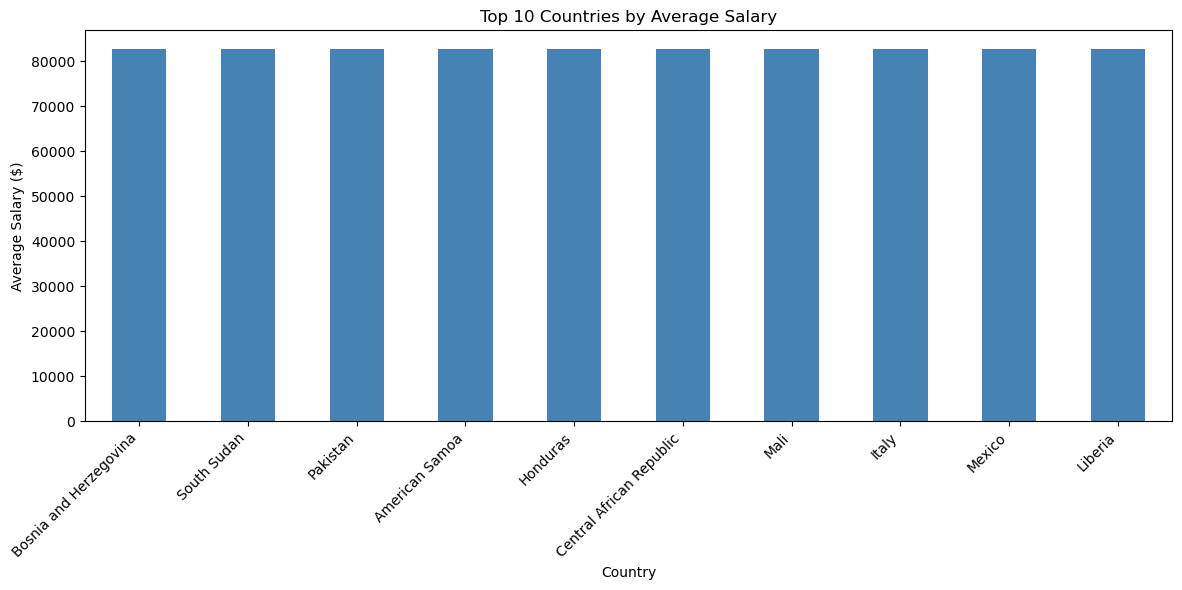

In [9]:
# Bar chart - top 10 countries by salary
top_countries = df.groupby('Country')['Salary_Avg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_countries.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries by Average Salary')
plt.xlabel('Country')
plt.ylabel('Average Salary ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

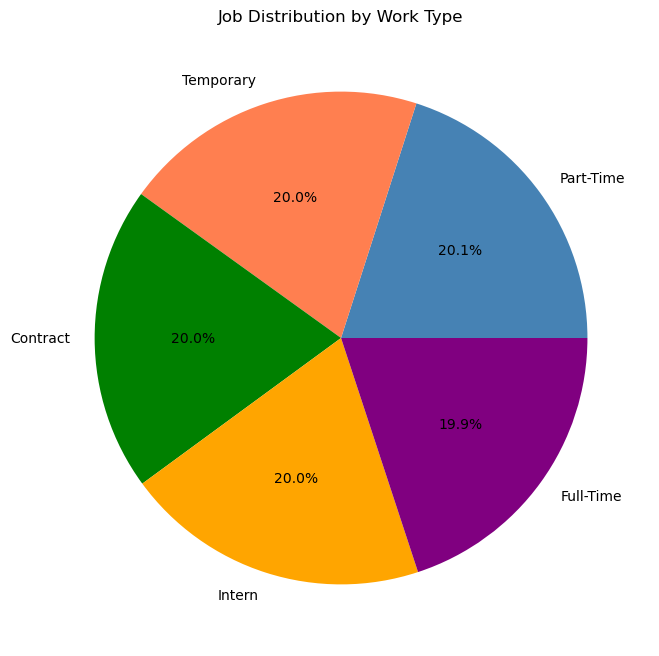

In [10]:
# Work Type distribution
work_type_counts = df['Work Type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(work_type_counts, 
        labels=work_type_counts.index, 
        autopct='%1.1f%%',
        colors=['steelblue', 'coral', 'green', 'orange', 'purple'])
plt.title('Job Distribution by Work Type')
plt.show()

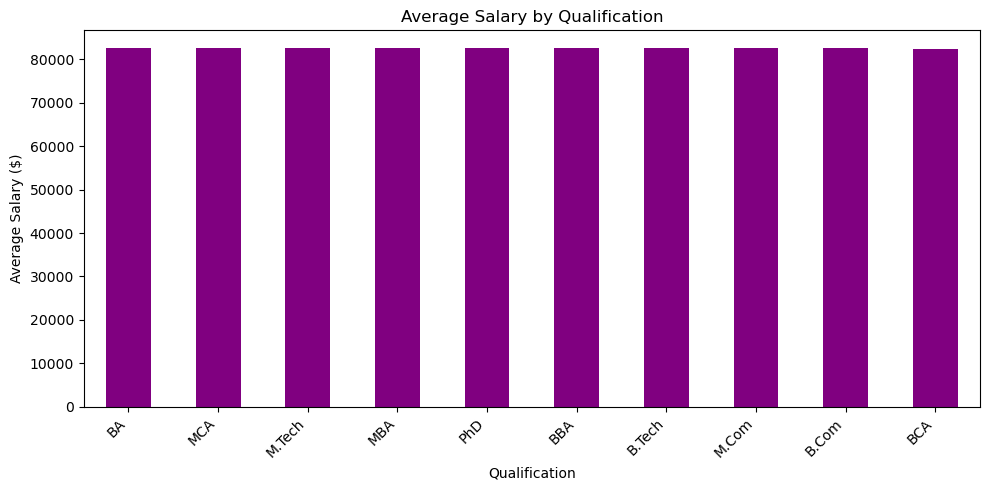

In [11]:
# Qualification vs Average Salary
qual_salary = df.groupby('Qualifications')['Salary_Avg'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
qual_salary.plot(kind='bar', color='purple')
plt.title('Average Salary by Qualification')
plt.xlabel('Qualification')
plt.ylabel('Average Salary ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

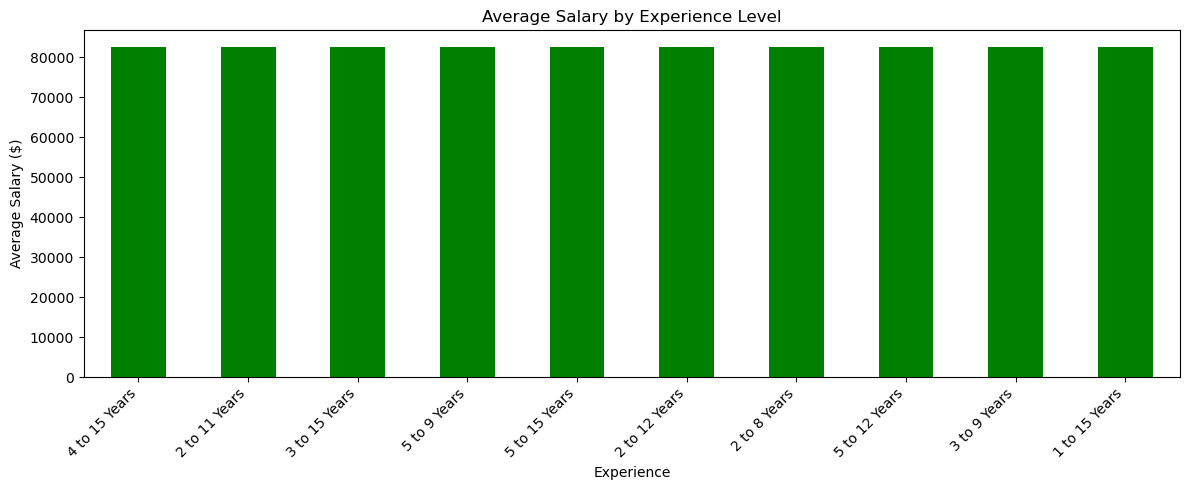

In [12]:
# Experience vs Average Salary
exp_salary = df.groupby('Experience')['Salary_Avg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
exp_salary.plot(kind='bar', color='green')
plt.title('Average Salary by Experience Level')
plt.xlabel('Experience')
plt.ylabel('Average Salary ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
import sqlite3

# SQLite database create cheyyi
conn = sqlite3.connect('jobs_analysis.db')

# Clean column names cheyyi first - spaces remove cheyyi
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

# Database lo save cheyyi
df.to_sql('jobs', conn, if_exists='replace', index=False)

print("Done! Total rows:", pd.read_sql('SELECT COUNT(*) FROM jobs', conn).iloc[0,0])

Done! Total rows: 1615940


In [ ]:
# Query 1: Top 10 Job Titles by count
query1 = """
SELECT job_title, 
       COUNT(*) as total_jobs
FROM jobs
GROUP BY job_title
ORDER BY total_jobs DESC
LIMIT 10;
"""

result1 = pd.read_sql(query1, conn)
print(result1)

In [ ]:
# Query 2: Average salary by work type
query2 = """
SELECT work_type,
       ROUND(AVG(salary_avg), 2) as avg_salary,
       COUNT(*) as total_jobs
FROM jobs
GROUP BY work_type
ORDER BY avg_salary DESC;
"""

result2 = pd.read_sql(query2, conn)
print(result2)

In [ ]:
# Query 3: Top 3 jobs per work type by salary
query3 = """
SELECT * FROM (
    SELECT work_type,
           job_title,
           ROUND(salary_avg, 2) as salary,
           RANK() OVER (PARTITION BY work_type 
                        ORDER BY salary_avg DESC) as salary_rank
    FROM jobs
) ranked
WHERE salary_rank <= 3;
"""

result3 = pd.read_sql(query3, conn)
print(result3)

In [ ]:
# Query 4: Top 5 highest paying job titles
query4 = """
SELECT job_title,
       ROUND(AVG(salary_avg), 2) as avg_salary,
       COUNT(*) as total_jobs
FROM jobs
GROUP BY job_title
ORDER BY avg_salary DESC
LIMIT 5;
"""

result4 = pd.read_sql(query4, conn)
print(result4)

In [22]:
import sqlite3
import pandas as pd
conn = sqlite3.connect('jobs_analysis.db')
print("Rows:", pd.read_sql('SELECT COUNT(*) FROM jobs', conn).iloc[0,0])

Rows: 1615940


In [23]:
# Power BI kosam CSV export cheyyi
df.to_csv('jobs_powerbi.csv', index=False)
print("CSV exported successfully!")

CSV exported successfully!


In [24]:
import os
print(os.getcwd())

C:\Users\SRINIVAS PADMA
